## Feature Engineering and Preprocessing

**Project:** Windows Log Intelligence: Anomaly Detection & Incident Reporting  
**Goal:** Transform raw 13-column Windows Event Log into a rich numeric feature matrix for the Autoencoder.  

### Feature Groups Built Here
| Group | Features | Dim |
|---|---|---|
| Temporal | hour, dow, month, day, year, flags | 8 |
| Categorical (Label Encoded) | MachineName, Category, EntryType, Source, country, regionName, city, timezone, isp | 9 |
| Message TF-IDF | top-50 unigrams + bigrams | 50 |
| Message Stats | char length, word count | 2 |
| **Total** | | **~69** |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 130})

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)



### Load Data

In [2]:
df = pd.read_csv('../data/raw/eventlog.csv', low_memory=False)
df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'], errors='coerce', infer_datetime_format=True)
df['TimeGenerated'].fillna(pd.Timestamp('2000-01-01'), inplace=True)

CATEGORICAL_COLS = ['MachineName','Category','EntryType','Source','country','regionName','city','timezone','isp']

for col in CATEGORICAL_COLS:
    df[col] = df[col].fillna('Unknown').astype(str).str.strip()

df['Message'] = df['Message'].fillna('').astype(str)
df['zip']     = df['zip'].fillna('00000').astype(str)

print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (158184, 13)


,#,MachineName,Category,EntryType,Message,Source,TimeGenerated,country,regionName,city,zip,timezone,isp
0,1,LAPTOP-1MKMTVPM,0,Information,Successfully scheduled Software Protection ser...,Software Protection Platform Service,2020-11-14 08:41:00,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
1,2,LAPTOP-1MKMTVPM,Logging/Recovery,Error,"svchost (13360,R,98) TILEREPOSITORYS-1-5-18: E...",ESENT,2020-11-14 08:25:00,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
2,3,LAPTOP-1MKMTVPM,Logging/Recovery,Error,"svchost (15040,R,98) TILEREPOSITORYS-1-5-18: E...",ESENT,2020-11-14 08:35:00,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise


### Temporal Feature Engineering


From the **TimeGenerated** timestamp it extracts calendar components (hour, day, month, year, quarter, day-of-week) and adds behavioral flags like after_hours, late_night, and weekend — useful for spotting unusual login times. 
It also applies cyclical (sin/cos) encoding for hour and day-of-week so that,e.g., 11pm and midnight are numerically close rather than far apart.

In [5]:
ts = df['TimeGenerated']

temporal_df = pd.DataFrame({
    'hour'        : ts.dt.hour,
    'dayofweek'   : ts.dt.dayofweek,       # 0=Mon, 6=Sun
    'day'         : ts.dt.day,
    'month'       : ts.dt.month,
    'year'        : ts.dt.year,
    'quarter'     : ts.dt.quarter,
    'after_hours' : ((ts.dt.hour < 6) | (ts.dt.hour >= 22)).astype(int),
    'late_night'  : (ts.dt.hour >= 22).astype(int),
    'weekend'     : (ts.dt.dayofweek >= 5).astype(int),
    # Cyclical encoding for hour (avoids ordinal boundary)
    'hour_sin'    : np.sin(2 * np.pi * ts.dt.hour / 24),
    'hour_cos'    : np.cos(2 * np.pi * ts.dt.hour / 24),
    'dow_sin'     : np.sin(2 * np.pi * ts.dt.dayofweek / 7),
    'dow_cos'     : np.cos(2 * np.pi * ts.dt.dayofweek / 7),
})

print(f'Temporal features shape: {temporal_df.shape}')
temporal_df.head()

Temporal features shape: (158184, 13)


,hour,dayofweek,day,month,year,quarter,after_hours,late_night,weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,8,5,14,11,2020,4,0,0,1,0.866025,-0.5,-0.974928,-0.222521
1,8,5,14,11,2020,4,0,0,1,0.866025,-0.5,-0.974928,-0.222521
2,8,5,14,11,2020,4,0,0,1,0.866025,-0.5,-0.974928,-0.222521
3,8,5,14,11,2020,4,0,0,1,0.866025,-0.5,-0.974928,-0.222521
4,8,5,14,11,2020,4,0,0,1,0.866025,-0.5,-0.974928,-0.222521


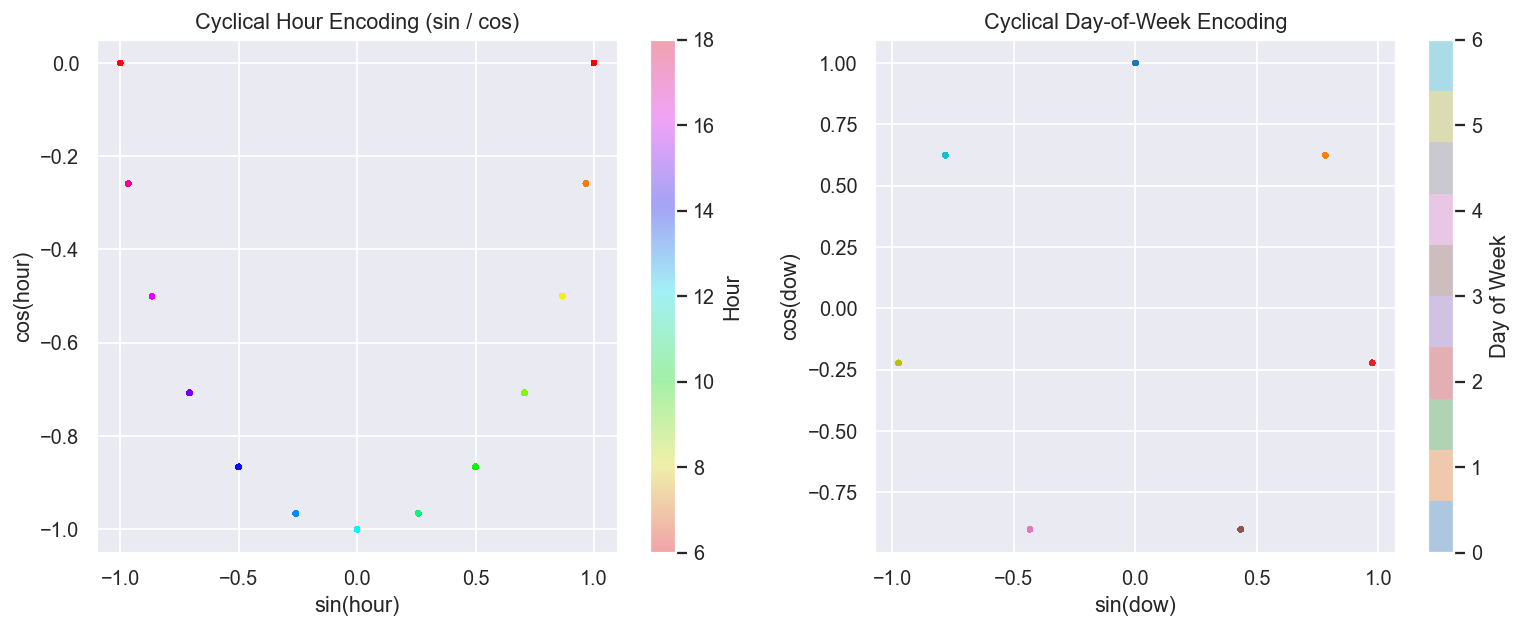

In [6]:
# Visualise cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(temporal_df['hour_sin'], temporal_df['hour_cos'], c=temporal_df['hour'], cmap='hsv', alpha=0.3, s=5)
plt.colorbar(sc1, ax=axes[0], label='Hour')
axes[0].set_title('Cyclical Hour Encoding (sin / cos)')
axes[0].set_xlabel('sin(hour)'); axes[0].set_ylabel('cos(hour)')

sc2 = axes[1].scatter(temporal_df['dow_sin'], temporal_df['dow_cos'], c=temporal_df['dayofweek'], cmap='tab10', alpha=0.3, s=5)
plt.colorbar(sc2, ax=axes[1], label='Day of Week')
axes[1].set_title('Cyclical Day-of-Week Encoding')
axes[1].set_xlabel('sin(dow)'); axes[1].set_ylabel('cos(dow)')

plt.tight_layout()
plt.savefig('../reports/fe_cyclical.png', dpi=150, bbox_inches='tight')
plt.show()

### Label Encoding (Categorical Columns)

In [7]:
label_encoders = {}
cat_features   = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    cat_features[f'le_{col}'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f'  {col:<15} → {le.classes_.shape[0]:>5,} unique classes')

cat_df = pd.DataFrame(cat_features)
print(f'\nCategorical feature matrix: {cat_df.shape}')
cat_df.head()

  MachineName     →     9 unique classes
  Category        →    19 unique classes
  EntryType       →     4 unique classes
  Source          →    81 unique classes
  country         →     1 unique classes
  regionName      →     1 unique classes
  city            →     2 unique classes
  timezone        →     1 unique classes
  isp             →    10 unique classes

Categorical feature matrix: (158184, 9)


,le_MachineName,le_Category,le_EntryType,le_Source,le_country,le_regionName,le_city,le_timezone,le_isp
0,5,7,2,56,0,0,0,0,3
1,5,13,1,23,0,0,0,0,3
2,5,13,1,23,0,0,0,0,3
3,5,7,2,56,0,0,0,0,3
4,5,7,2,61,0,0,0,0,3


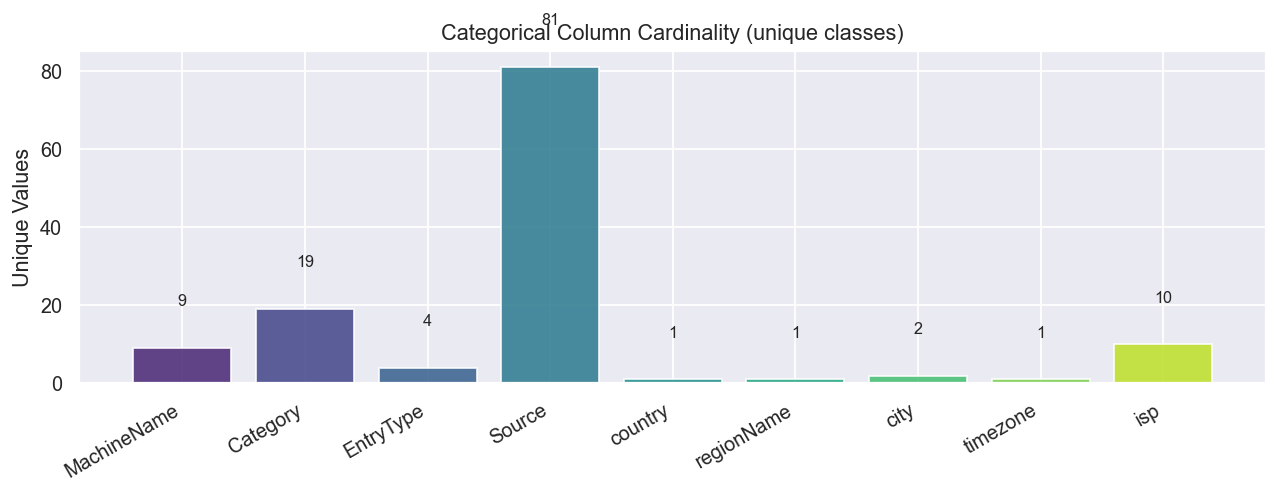

In [8]:
# Visualise encoded cardinality
cardinalities = {col: len(le.classes_) for col, le in label_encoders.items()}
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cardinalities.keys(), cardinalities.values(),color=sns.color_palette('viridis', len(cardinalities)), alpha=0.85)
for bar, val in zip(bars, cardinalities.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Categorical Column Cardinality (unique classes)')
ax.set_ylabel('Unique Values')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/fe_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

###  Message TF-IDF Features


The free-text Message field is vectorized using a TfidfVectorizer that extracts the top 50 most informative unigrams and bigrams (excluding English stop words). This captures which log message terms are most distinctive.

In [10]:
tfidf = TfidfVectorizer(
    max_features=50,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

tfidf_matrix = tfidf.fit_transform(df['Message']).toarray()
tfidf_cols   = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
tfidf_df     = pd.DataFrame(tfidf_matrix, columns=tfidf_cols)

print(f'TF-IDF feature matrix: {tfidf_df.shape}')
print(f'Top terms: {tfidf.get_feature_names_out()[:10]}')

TF-IDF feature matrix: (158184, 50)
Top terms: ['0k' '0k 0k' '0k fs' '0k pf' '0x00000000' '0xc004f014' '10' 'cm'
 'cm pgrf' 'database']


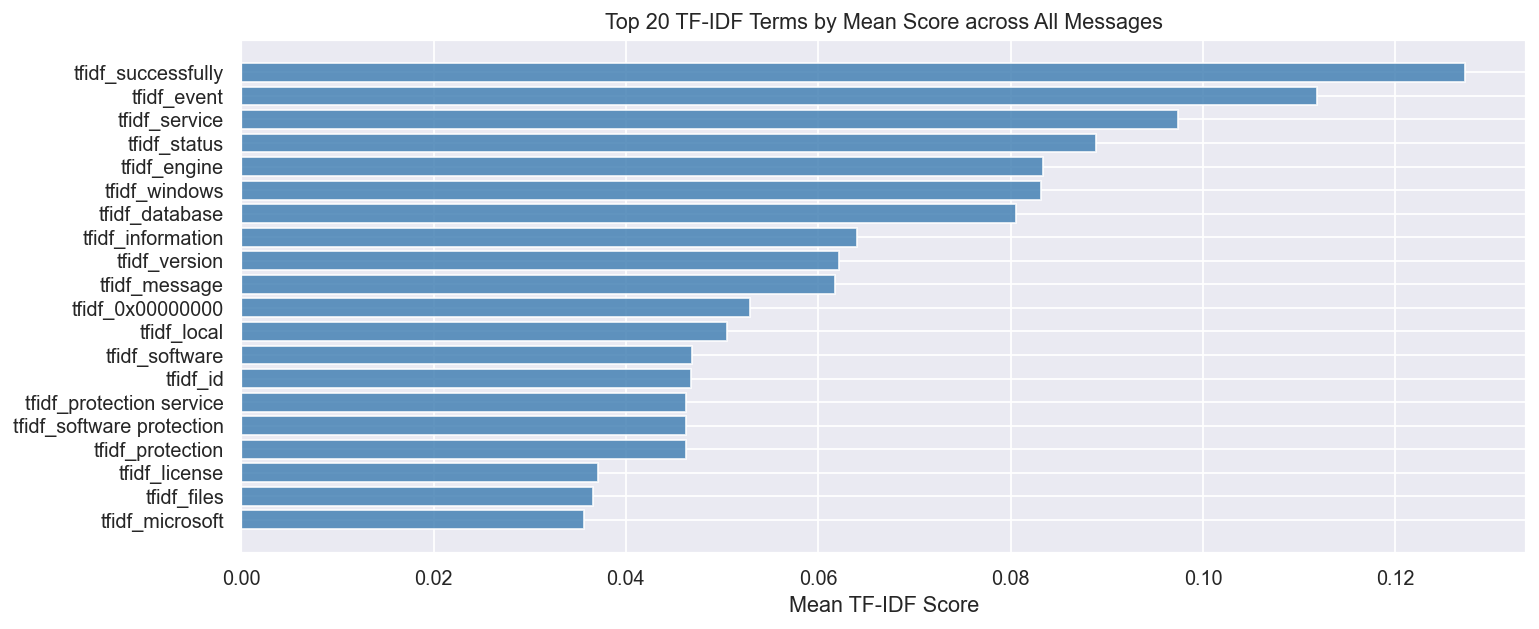

In [11]:
# Visualise top TF-IDF terms by mean score
term_importance = tfidf_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top20 = term_importance.head(20)
bars  = ax.barh(top20.index[::-1], top20.values[::-1],color='steelblue', alpha=0.85)
ax.set_title('Top 20 TF-IDF Terms by Mean Score across All Messages')
ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('../reports/fe_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

###  Message Statistic Features

Beyond TF-IDF, 7 hand-crafted statistics are extracted from the message text: character length, word count, uppercase/digit character ratios, and binary flags for whether the message contains an IP address, error/failure keywords, or login-related keywords. These are lightweight but highly interpretable signals.

In [12]:
msg_stats_df = pd.DataFrame({
    'msg_len'        : df['Message'].str.len(),
    'msg_word_count' : df['Message'].str.split().str.len().fillna(0),
    'msg_upper_ratio': df['Message'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)),
    'msg_digit_ratio': df['Message'].apply(lambda x: sum(1 for c in x if c.isdigit()) / max(len(x), 1)),
    'msg_has_ip'     : df['Message'].str.contains(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}',regex=True, na=False).astype(int),
    'msg_has_error'  : df['Message'].str.lower().str.contains('error|fail|denied|critical',na=False).astype(int),
    'msg_has_login'  : df['Message'].str.lower().str.contains('logon|login|authentication',na=False).astype(int),
})

print(f'Message stat features: {msg_stats_df.shape}')
msg_stats_df.describe().round(3)

Message stat features: (158184, 7)


,msg_len,msg_word_count,msg_upper_ratio,msg_digit_ratio,msg_has_ip,msg_has_error,msg_has_login
count,158184.000,158184.000,158184.000,158184.000,158184.000,158184.000,158184.000
mean,317.847,34.299,0.100,0.104,0.093,0.107,0.073
std,835.597,58.935,0.090,0.117,0.290,0.309,0.260
min,16.000,2.000,0.008,0.000,0.000,0.000,0.000
25%,77.000,9.000,0.047,0.000,0.000,0.000,0.000
50%,169.000,13.000,0.070,0.057,0.000,0.000,0.000
75%,311.000,41.000,0.119,0.180,0.000,0.000,0.000
max,24463.000,648.000,0.444,0.472,1.000,1.000,1.000


Events with IP address in message : 14,677
Events with error/fail keywords   : 16,867
Events with login keywords        : 11,541


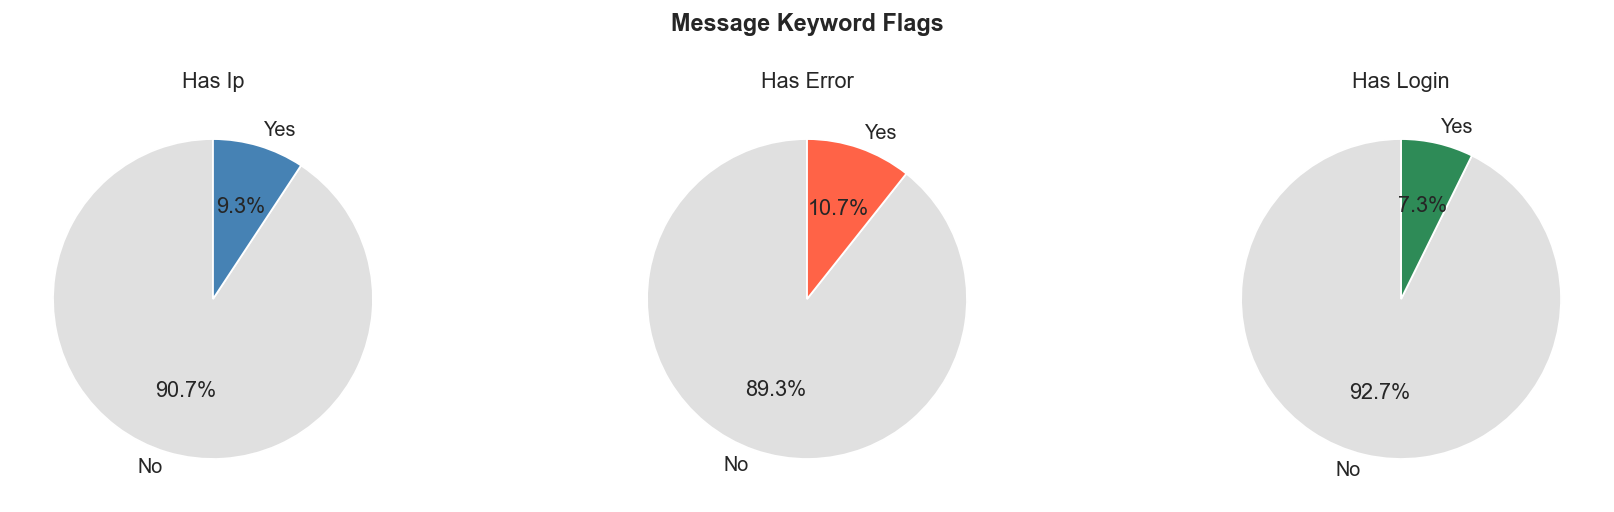

In [13]:
# IP address & error keyword analysis
print(f'Events with IP address in message : {msg_stats_df["msg_has_ip"].sum():,}')
print(f'Events with error/fail keywords   : {msg_stats_df["msg_has_error"].sum():,}')
print(f'Events with login keywords        : {msg_stats_df["msg_has_login"].sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['msg_has_ip', 'msg_has_error', 'msg_has_login'], ['steelblue', 'tomato', 'seagreen']):
    counts = msg_stats_df[col].value_counts()
    ax.pie(counts, labels=['No','Yes'], autopct='%1.1f%%', colors=['#e0e0e0', color], startangle=90, wedgeprops={'edgecolor': 'white'})
    ax.set_title(col.replace('msg_has_', 'Has ').replace('_', ' ').title())

plt.suptitle('Message Keyword Flags', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fe_msg_flags.png', dpi=150, bbox_inches='tight')
plt.show()

### Combine All Features


All four feature groups are horizontally stacked into a single matrix of shape (158,184 × 79), then StandardScaler normalizes everything to zero mean and unit variance — a requirement for Autoencoders to learn effectively.

In [15]:
X = np.hstack([
    temporal_df.values,
    cat_df.values,
    tfidf_df.values,
    msg_stats_df.values,
]).astype(np.float32)

X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)

print(f'Combined feature matrix: {X.shape}')
print(f'Feature breakdown:')
print(f'  Temporal   : {temporal_df.shape[1]}')
print(f'  Categorical: {cat_df.shape[1]}')
print(f'  TF-IDF     : {tfidf_df.shape[1]}')
print(f'  Msg Stats  : {msg_stats_df.shape[1]}')
print(f'  TOTAL      : {X.shape[1]}')

Combined feature matrix: (158184, 79)
Feature breakdown:
  Temporal   : 13
  Categorical: 9
  TF-IDF     : 50
  Msg Stats  : 7
  TOTAL      : 79


### StandardScaler Normalization

Scaled matrix: (158184, 79)
Mean (should be ~0): 0.000000
Std  (should be ~1): 0.967837


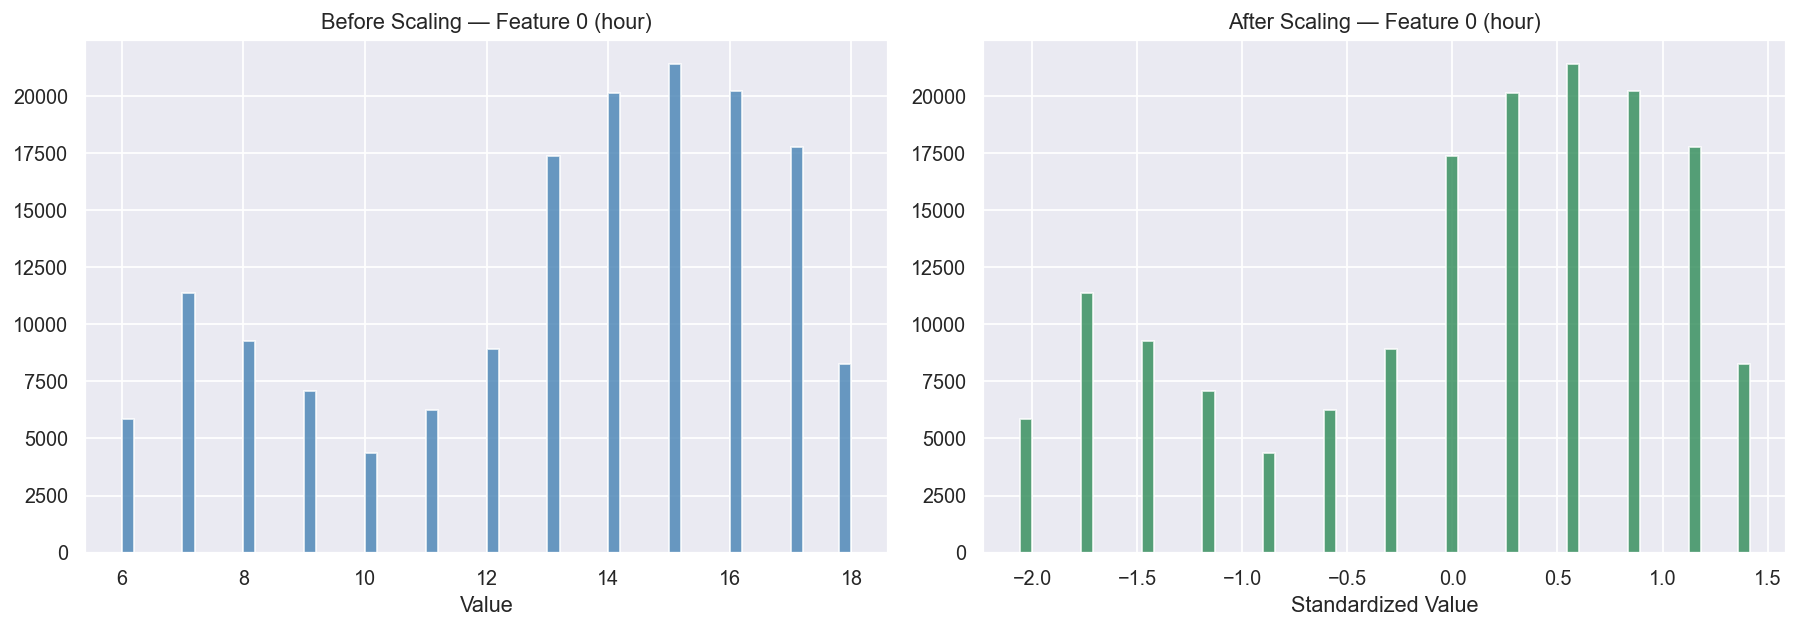

In [16]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

print(f'Scaled matrix: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean():.6f}')
print(f'Std  (should be ~1): {X_scaled.std():.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(X[:, 0].flatten(), bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Before Scaling — Feature 0 (hour)')
axes[0].set_xlabel('Value')

axes[1].hist(X_scaled[:, 0].flatten(), bins=60, color='seagreen', alpha=0.8)
axes[1].set_title('After Scaling — Feature 0 (hour)')
axes[1].set_xlabel('Standardized Value')

plt.tight_layout()
plt.savefig('../reports/fe_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation Analysis

A heatmap of the first 20 features checks for redundancy among temporal and categorical features.

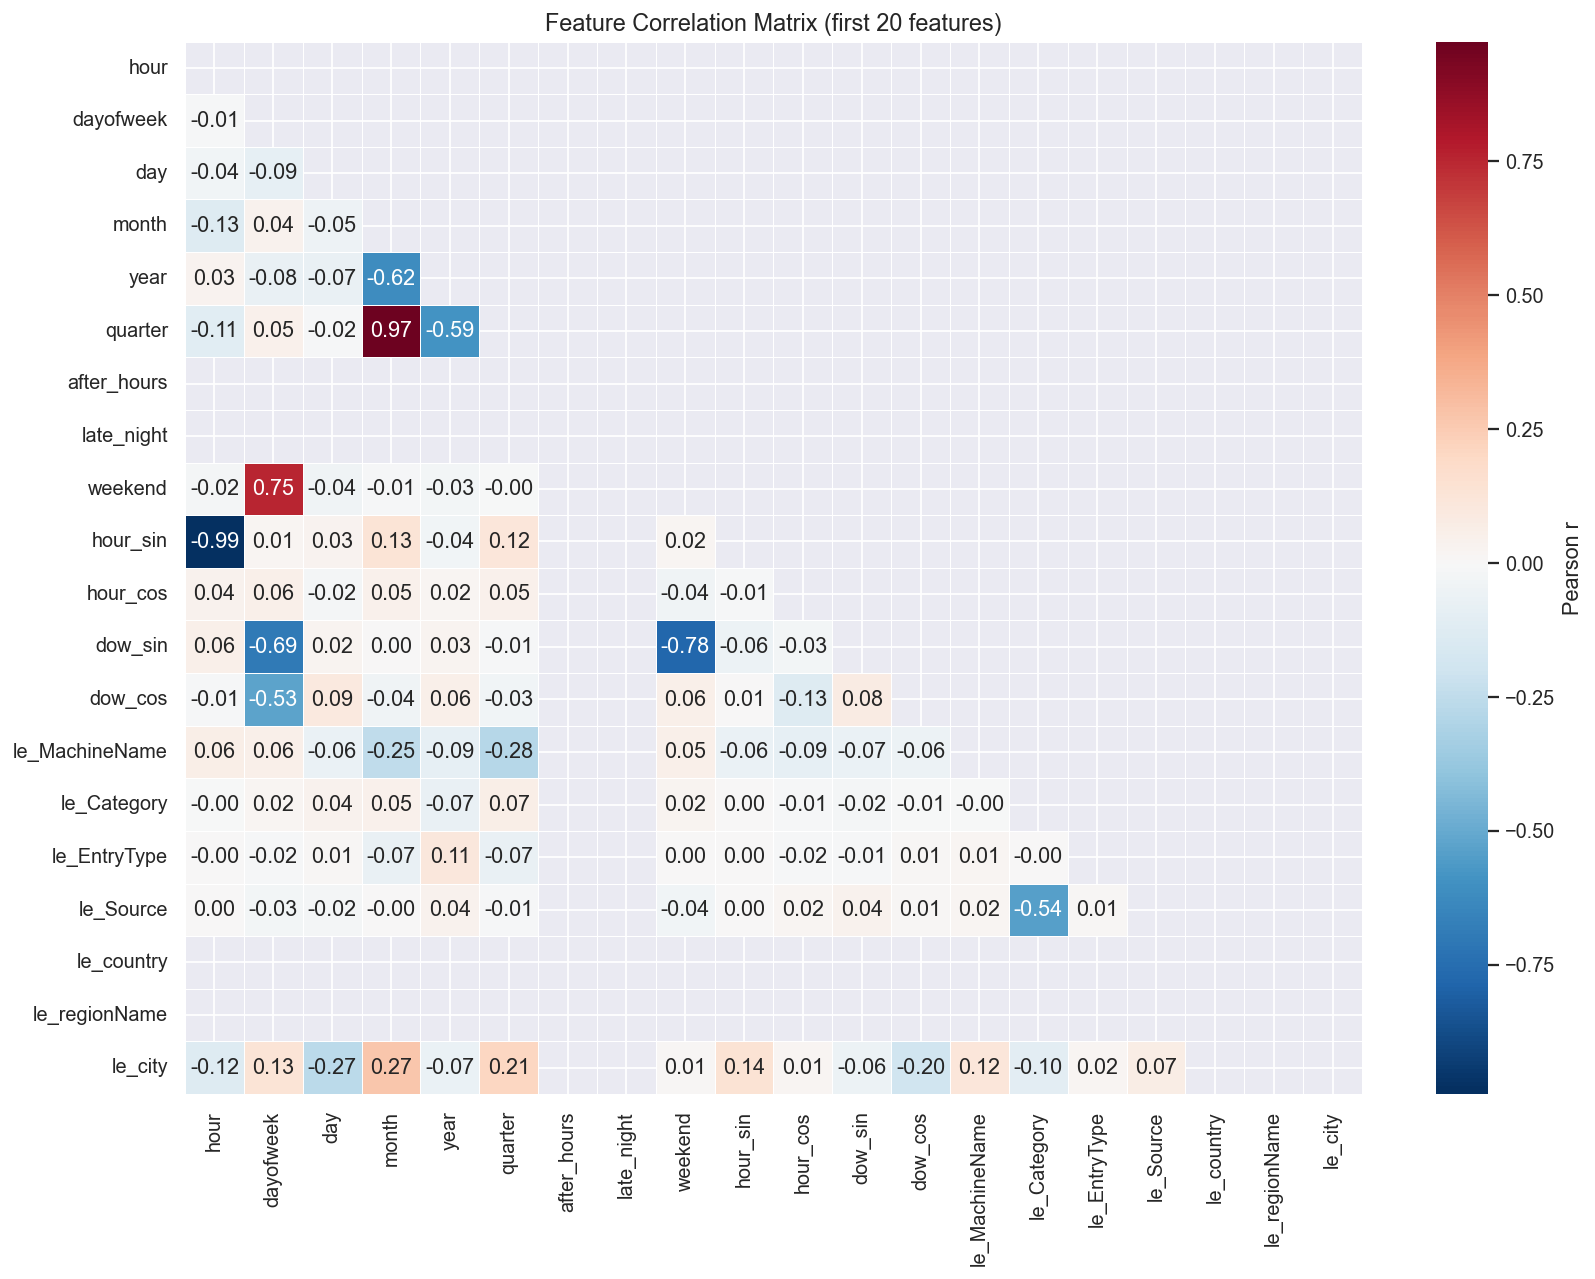

In [17]:
# Correlation of the first 20 features (temporal + categorical)
n_inspect  = 20
all_names  = (list(temporal_df.columns) + list(cat_df.columns) + tfidf_cols + list(msg_stats_df.columns))
corr_df    = pd.DataFrame(X_scaled[:, :n_inspect], columns=all_names[:n_inspect])
corr_mat   = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (first 20 features)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fe_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save feature matrix
np.save('../data/processed/features.npy', X_scaled)

# Save preprocessor artifacts
joblib.dump(scaler,         '../models/preprocessors/scaler.pkl')
joblib.dump(label_encoders, '../models/preprocessors/label_encoders.pkl')
joblib.dump(tfidf,          '../models/preprocessors/tfidf.pkl')
joblib.dump(all_names,      '../models/preprocessors/feature_names.pkl')

# Save processed df with basic features for later use
df_meta = df[['#','MachineName','Category','EntryType','Source','TimeGenerated','country','regionName','city','isp']].copy()
df_meta.to_csv('../data/processed/metadata.csv', index=False)

print('Saved:')
print('  ../data/processed/features.npy')
print('  ../data/processed/metadata.csv')
print('  ../models/preprocessors/scaler.pkl')
print('  ../models/preprocessors/label_encoders.pkl')
print('  ../models/preprocessors/tfidf.pkl')
print('  ../models/preprocessors/feature_names.pkl')
print(f'\n shape: {X_scaled.shape}')


Saved:
  ../data/processed/features.npy
  ../data/processed/metadata.csv
  ../models/preprocessors/scaler.pkl
  ../models/preprocessors/label_encoders.pkl
  ../models/preprocessors/tfidf.pkl
  ../models/preprocessors/feature_names.pkl

 shape: (158184, 79)
